In [1]:
from xyzrender import load, render, orient, build_config
from xyzrender.types import VectorArrow
import numpy as np
from automol import Geometry
from learn_vrc_tst import geom, View
from scipy.spatial.transform import Rotation
from pathlib import Path

In [2]:
file_in = "tert-butanol-triamine-in.xyz"
file_out = "tert-butanol-triamine.xyz"
file_svg = Path(file_out).with_suffix(".svg")

In [3]:
# Same tetrahedral basis as tert-butanol.ipynb: one vertex on +z (O, "straight up"
# from the central carbon), the other three as a downward tripod. v1 is the tripod
# vector with y = 0, tilted toward -x ("left"), matching the O-H tilt.
v0 = np.array([0.0, 0.0, 1.0])
v1 = np.array([-2 * np.sqrt(2) / 3, 0.0, -1 / 3])
v2 = np.array([np.sqrt(2) / 3, np.sqrt(6) / 3, -1 / 3])
v3 = np.array([np.sqrt(2) / 3, -np.sqrt(6) / 3, -1 / 3])

XY_DIST = 1.5  # C-O, C-N bond length (Angstrom)
XH_DIST = 1.2  # X-H bond length (Angstrom)

c0 = np.zeros(3)
o = XY_DIST * v0

# O-H: 109.5 degree angle from the O-C0 bond, tilted left, in the same plane as N1.
h_o = o + XH_DIST * np.array([-2 * np.sqrt(2) / 3, 0.0, 1 / 3])

dirs = {"v0": v0, "v1": v1, "v2": v2, "v3": v3}


def amine_group(back_key):
    """Build one N + its 2 "up" H's + 2 geometrically "inverted" H's.

    In tert-butanol.ipynb, the methyl carbon at `back_key` had 3 H's along the
    "opposite set" {-v0, -v_j, -v_k} (excluding its own back-bond -v_i). Here we
    drop the -v0 ("downward") direction, keeping only the two "up" H's -v_j, -v_k
    -- a proper pyramidal, "umbrella up" amine geometry.

    We then add duplicate, "inverted" copies of those two H's: each is reflected
    through the plane that contains the C0-N bond and is perpendicular to the
    C0-N-H_down plane (H_down being the now-dropped -v0 direction). That plane
    passes through N, contains direction v_i, and has unit normal
    n_hat = normalize(v0 - (v0 . v_i) v_i) = normalize(v0 + v_i / 3)
    (since v0 . v_i = -1/3 for every tripod direction). Reflecting a direction d
    through it: reflect(d) = d - 2 (d . n_hat) n_hat.
    """
    v_i = dirs[back_key]
    n = v0 + v_i / 3
    n_hat = n / np.linalg.norm(n)

    n_pos = XY_DIST * v_i
    up_dirs = [-dirs[k] for k in ("v0", "v1", "v2", "v3") if k not in (back_key, "v0")]
    up_positions = [n_pos + XH_DIST * d for d in up_dirs]

    def reflect(d):
        return d - 2 * np.dot(d, n_hat) * n_hat

    inv_positions = [n_pos + XH_DIST * reflect(d) for d in up_dirs]
    return n_pos, up_positions, inv_positions


n1, n1_up, n1_inv = amine_group("v1")
n2, n2_up, n2_inv = amine_group("v2")
n3, n3_up, n3_inv = amine_group("v3")

symbols = (
    ["C", "O", "H"]
    + ["N"] + ["H"] * 4
    + ["N"] + ["H"] * 4
    + ["N"] + ["H"] * 4
)
coordinates = np.array(
    [c0, o, h_o]
    + [n1, *n1_up, *n1_inv]
    + [n2, *n2_up, *n2_inv]
    + [n3, *n3_up, *n3_inv]
)
geo = Geometry(symbols=symbols, coordinates=coordinates)
geom.write_xyz_file(geo, file_in)

In [ ]:
geo = geom.read_xyz_file(file_in)
# geo = geom.rotate(geo, rot=Rotation.from_euler("xy", [-90, -30], degrees=True))
# geo = geom.rotate(geo, rot=Rotation.from_euler("x", [40], degrees=True))
geom.write_xyz_file(geo, file_out)

view = View()
view.add_geometry(geo, label=True)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
cfg = build_config(
  config_name="flat", orient=False, atom_scale=3, bond_width=25,
  bond_color="#000000", atom_stroke_width=3, hy=True, bo=False, fog=False
)

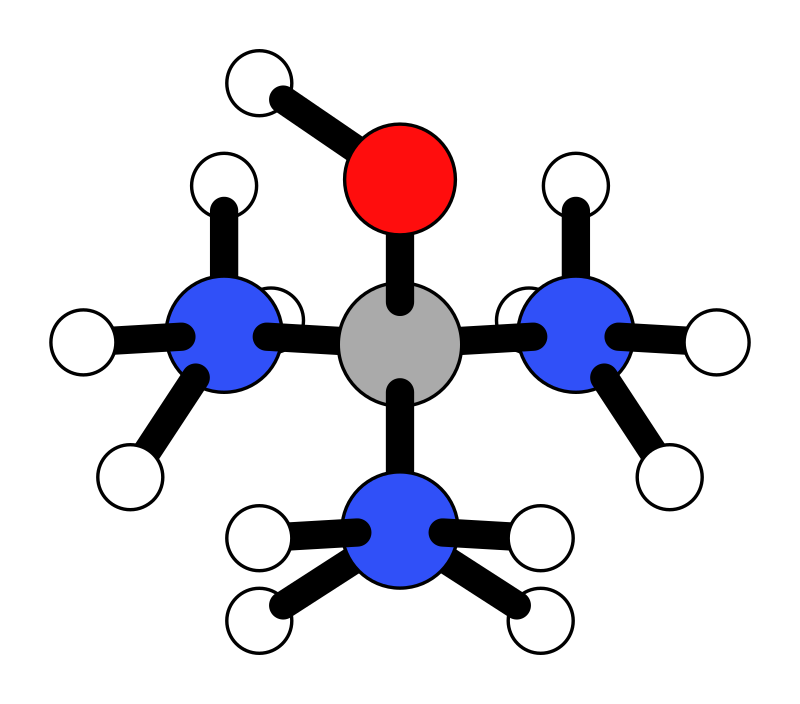

In [6]:
mol = load(file_out)
render(mol, output=file_svg, config=cfg)